# Loading Data and Importing Packages

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

In [2]:
feature_matrix = pd.read_csv("email_features.csv")

In [3]:
feature_matrix.head()

,email_index,custodian,folder_source,word_count,sentence_count,avg_sentence_len,personal_pronouns_count,negations_count,uncertainty_count,emotive_language_count,cognitive_process_count,finance_words_count,authority_words_count,fraud_words_count
0,0,lay-k,deleted_items,31,3,7.000000,0,1,0,0,0,0,0,0
1,1,lay-k,deleted_items,1489,38,30.894737,0,1,0,0,0,0,0,0
2,2,lay-k,discussion_threads,84,3,24.000000,0,1,0,0,0,0,0,0
3,3,lay-k,discussion_threads,12,1,11.000000,0,1,0,0,0,0,0,0
4,4,lay-k,discussion_threads,103,4,22.750000,0,1,0,0,0,0,0,0


# Scaling

In [4]:
num_features = feature_matrix.select_dtypes(include='number').drop(columns=['email_index'])

In [5]:
x_num = num_features.copy()

In [6]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(x_num)

# PCA

In [7]:
pca = PCA()
X_pca = pca.fit_transform(X_num_scaled)
var_ratio = pca.explained_variance_ratio_
print(var_ratio)

[0.61760556 0.34546672 0.03692772 0.         0.         0.
 0.         0.         0.         0.         0.        ]


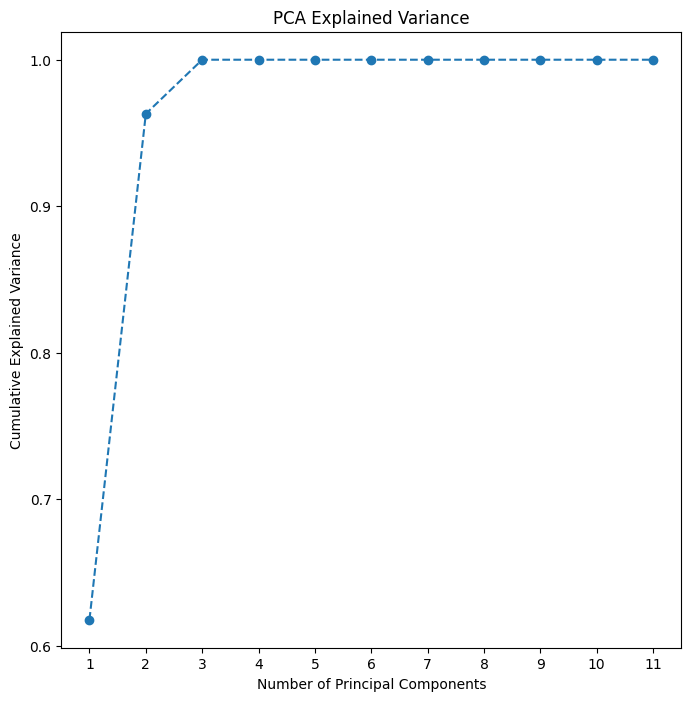

In [8]:
plt.figure(figsize=(8,8))
plt.plot(range(1, len(var_ratio)+1),
         np.cumsum(var_ratio),
         marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.yticks([0.6, 0.7, 0.8, 0.9, 1.0])
plt.xticks(range(1,12))
plt.show()

In [9]:
X_pca_dropped = X_pca[:, :3]
print(X_pca_dropped)

[[-8.13248987e-01 -9.21161959e-01  8.24742754e-02]
 [ 3.38952455e+00  8.03203343e-02  4.60946730e-01]
 [-7.06960907e-01 -1.96285953e-01  2.25250039e-02]
 ...
 [-2.20799330e-01  3.80301233e-01  6.94243451e-02]
 [-9.71533012e-01 -1.15689264e+00  1.85818132e-01]
 [ 3.10982272e-02 -1.69444660e-02 -1.45790134e-03]]


In [10]:
pca_columns = [f'PC{i+1}' for i in range(X_pca_dropped.shape[1])]
pca_df = pd.DataFrame(X_pca_dropped, columns=pca_columns)
pca_df['email_index'] = feature_matrix['email_index']
pca_df.to_csv("feature_matrix_pca.csv", index=False)

# Anomaly Detection and Scoring

## Model 1: Isolation Forest

### Model 1.1: PCA

In [11]:
best_n = None
best_std = -1

In [12]:
for n in [100, 200, 300]:
    iso_forest = IsolationForest(n_estimators=n, random_state=42)
    iso_forest.fit(X_pca_dropped)
    pred = iso_forest.predict(X_pca_dropped)
    score = iso_forest.decision_function(X_pca_dropped)
    if score.std() > best_std: 
        best_std = score.std()
        best_n = n
        best_iso_forest = iso_forest
        best_pred = pred
        best_score = score

In [13]:
feature_matrix['anomaly_score_pca'] = iso_forest.decision_function(X_pca_dropped)
feature_matrix['is_anomaly_pca'] = iso_forest.predict(X_pca_dropped)  # -1 = anomaly, 1 = normal

### Model 1.2: Feature Matrix

In [14]:
best_n_fm = None
best_std_fm = -1

In [15]:
for n_fm in [100, 200, 300]:
    iso_forest_fm = IsolationForest(n_estimators=n_fm, random_state=42)
    iso_forest_fm.fit(X_num_scaled)
    pred_fm = iso_forest_fm.predict(X_num_scaled)
    score_fm = iso_forest_fm.decision_function(X_num_scaled)
    if score_fm.std() > best_std_fm: 
        best_std_fm = score_fm.std()
        best_n_fm = n_fm
        best_iso_forest_fm = iso_forest_fm
        best_pred_fm = pred_fm
        best_score_fm = score_fm

In [16]:
feature_matrix['anomaly_score_fm'] = iso_forest_fm.decision_function(X_num_scaled)
feature_matrix['is_anomaly_fm'] = iso_forest_fm.predict(X_num_scaled)

### Comparing PCA model and Feature Matrix model

In [17]:
if best_std > best_std_fm:
    print("PCA model is better")
    feature_matrix['anomaly_score_best'] = best_score
    feature_matrix['is_anomaly_best'] = best_pred
else:
    print("Feature matrix model is better")
    feature_matrix['anomaly_score_best'] = best_score_fm
    feature_matrix['is_anomaly_best'] = best_pred_fm

PCA model is better


In [18]:
print("PCA best std:", best_std, "n_estimators:", best_n)
print("Feature matrix best std:", best_std_fm, "n_estimators:", best_n_fm)

PCA best std: 0.08011674598801417 n_estimators: 300
Feature matrix best std: 0.07492563289457282 n_estimators: 200


### Best Model

In [19]:
best_iso_pca = IsolationForest(n_estimators=300, random_state=42)
best_iso_pca.fit(X_pca_dropped)
feature_matrix['anomaly_score_pca'] = best_iso_pca.decision_function(X_pca_dropped)
feature_matrix['is_anomaly_pca'] = best_iso_pca.predict(X_pca_dropped)

## Model 2: SVM

In [20]:
nu_values = [0.01, 0.05, 0.1, 0.15]
gamma_values = ['scale', 'auto']

### Model 2.1: PCA

In [21]:
best_score = -1
best_svm = None

In [22]:
for nu in nu_values:
    for gamma in gamma_values:
        svm = OneClassSVM(nu=nu, gamma=gamma)
        svm.fit(X_pca_dropped)
        score = svm.decision_function(X_pca_dropped)
        if score.std() > best_score:
            best_score = score.std()
            best_svm = svm
            best_nu = nu
            best_gamma = gamma
            best_pred = svm.predict(X_pca_dropped)
            best_score_array = score

In [23]:
feature_matrix['svm_score_pca'] = best_score_array
feature_matrix['is_anomaly_svm_pca'] = best_pred

### Model 2.2: Feature Matrix

In [24]:
best_score_fm = -1
best_svm_fm = None

In [25]:
for nu in nu_values:
    for gamma in gamma_values:
        svm_fm = OneClassSVM(nu=nu, gamma=gamma)
        svm_fm.fit(X_num_scaled)
        score_fm = svm_fm.decision_function(X_num_scaled)
        if score_fm.std() > best_score_fm:
            best_score_fm = score_fm.std()
            best_svm_fm = svm_fm
            best_nu_fm = nu
            best_gamma_fm = gamma
            best_pred_fm = svm_fm.predict(X_num_scaled)
            best_score_array_fm = score_fm

In [26]:
feature_matrix['svm_score_fm'] = best_score_array_fm
feature_matrix['is_anomaly_svm_fm'] = best_pred_fm

### Comparing PCA model and Feature Matrix model

In [27]:
if best_score > best_score_fm:
    print("Best SVM model: PCA")
    feature_matrix['svm_score_best'] = best_score_array
    feature_matrix['is_anomaly_svm_best'] = best_pred
else:
    print("Best SVM model: Feature Matrix")
    feature_matrix['svm_score_best'] = best_score_array_fm
    feature_matrix['is_anomaly_svm_best'] = best_pred_fm

Best SVM model: Feature Matrix


In [28]:
print("PCA best score:", best_score, "best svm:", best_svm)
print("Feature matrix best score:", best_score_fm, "best svm:", best_svm_fm)

PCA best score: 10.270588219439 best svm: OneClassSVM(nu=0.15)
Feature matrix best score: 21.346676924840956 best svm: OneClassSVM(gamma='auto', nu=0.15)


### Best Model

In [29]:
best_svm_fm = OneClassSVM(nu=0.15, gamma='auto')
best_svm_fm.fit(X_num_scaled)
feature_matrix['anomaly_score_svm'] = best_svm_fm.decision_function(X_num_scaled)
feature_matrix['is_anomaly_svm'] = best_svm_fm.predict(X_num_scaled)

# Normalizing scores as probabilities

In [30]:
score_iso = feature_matrix['anomaly_score_pca']
prob_iso = (score_iso - score_iso.min()) / (score_iso.max() - score_iso.min())
feature_matrix['deception_score_iso'] = (1 - prob_iso) * 100

In [31]:
score_svm = feature_matrix['anomaly_score_svm']
prob_svm = (score_svm - score_svm.min()) / (score_svm.max() - score_svm.min())
feature_matrix['deception_score_svm'] =  (1 - prob_svm) * 100

In [32]:
feature_matrix.head() # -1 = anomaly, 1 = normal, lower deception % = more normal, higher deception % = more anomalous

,email_index,custodian,folder_source,word_count,sentence_count,avg_sentence_len,personal_pronouns_count,negations_count,uncertainty_count,emotive_language_count,...,svm_score_pca,is_anomaly_svm_pca,svm_score_fm,is_anomaly_svm_fm,svm_score_best,is_anomaly_svm_best,anomaly_score_svm,is_anomaly_svm,deception_score_iso,deception_score_svm
0,0,lay-k,deleted_items,31,3,7.000000,0,1,0,0,...,1.947976,1,0.325262,1,0.325262,1,0.325262,1,12.608713,12.232076
1,1,lay-k,deleted_items,1489,38,30.894737,0,1,0,0,...,-7.799738,-1,-24.603962,-1,-24.603962,-1,-24.603962,-1,49.499633,26.196316
2,2,lay-k,discussion_threads,84,3,24.000000,0,1,0,0,...,5.536075,1,10.905865,1,10.905865,1,10.905865,1,1.919343,6.305294
3,3,lay-k,discussion_threads,12,1,11.000000,0,1,0,0,...,1.629698,1,0.715565,1,0.715565,1,0.715565,1,13.833187,12.013446
4,4,lay-k,discussion_threads,103,4,22.750000,0,1,0,0,...,6.525373,1,11.926536,1,11.926536,1,11.926536,1,0.709637,5.733560


In [33]:
feature_matrix['deception_score_final'] = feature_matrix[['deception_score_iso', 'deception_score_svm']].max(axis=1)

In [34]:
feature_matrix.head()

,email_index,custodian,folder_source,word_count,sentence_count,avg_sentence_len,personal_pronouns_count,negations_count,uncertainty_count,emotive_language_count,...,is_anomaly_svm_pca,svm_score_fm,is_anomaly_svm_fm,svm_score_best,is_anomaly_svm_best,anomaly_score_svm,is_anomaly_svm,deception_score_iso,deception_score_svm,deception_score_final
0,0,lay-k,deleted_items,31,3,7.000000,0,1,0,0,...,1,0.325262,1,0.325262,1,0.325262,1,12.608713,12.232076,12.608713
1,1,lay-k,deleted_items,1489,38,30.894737,0,1,0,0,...,-1,-24.603962,-1,-24.603962,-1,-24.603962,-1,49.499633,26.196316,49.499633
2,2,lay-k,discussion_threads,84,3,24.000000,0,1,0,0,...,1,10.905865,1,10.905865,1,10.905865,1,1.919343,6.305294,6.305294
3,3,lay-k,discussion_threads,12,1,11.000000,0,1,0,0,...,1,0.715565,1,0.715565,1,0.715565,1,13.833187,12.013446,13.833187
4,4,lay-k,discussion_threads,103,4,22.750000,0,1,0,0,...,1,11.926536,1,11.926536,1,11.926536,1,0.709637,5.733560,5.733560


# Deception Categories

In [35]:
bins = [0, 20, 40, 60, 80, 100]
labels = ['Not likely', 'Less likely', 'Moderately likely', ' More Likely', 'Highly likely']
feature_matrix['deception_category'] = pd.cut(feature_matrix['deception_score_final'], bins=bins, labels=labels, include_lowest=True)

In [36]:
feature_matrix.head()

,email_index,custodian,folder_source,word_count,sentence_count,avg_sentence_len,personal_pronouns_count,negations_count,uncertainty_count,emotive_language_count,...,svm_score_fm,is_anomaly_svm_fm,svm_score_best,is_anomaly_svm_best,anomaly_score_svm,is_anomaly_svm,deception_score_iso,deception_score_svm,deception_score_final,deception_category
0,0,lay-k,deleted_items,31,3,7.000000,0,1,0,0,...,0.325262,1,0.325262,1,0.325262,1,12.608713,12.232076,12.608713,Not likely
1,1,lay-k,deleted_items,1489,38,30.894737,0,1,0,0,...,-24.603962,-1,-24.603962,-1,-24.603962,-1,49.499633,26.196316,49.499633,Moderately likely
2,2,lay-k,discussion_threads,84,3,24.000000,0,1,0,0,...,10.905865,1,10.905865,1,10.905865,1,1.919343,6.305294,6.305294,Not likely
3,3,lay-k,discussion_threads,12,1,11.000000,0,1,0,0,...,0.715565,1,0.715565,1,0.715565,1,13.833187,12.013446,13.833187,Not likely
4,4,lay-k,discussion_threads,103,4,22.750000,0,1,0,0,...,11.926536,1,11.926536,1,11.926536,1,0.709637,5.733560,5.733560,Not likely


# Escalation

In [37]:
Review = []

for idx, row in feature_matrix.iterrows():
    if row['deception_score_final'] >= 70:
        feature_matrix['escalation'] = 'review'
        Review.append(idx)
    else: 
        feature_matrix['escalation'] = 'no review'

In [38]:
feature_matrix.head()

,email_index,custodian,folder_source,word_count,sentence_count,avg_sentence_len,personal_pronouns_count,negations_count,uncertainty_count,emotive_language_count,...,is_anomaly_svm_fm,svm_score_best,is_anomaly_svm_best,anomaly_score_svm,is_anomaly_svm,deception_score_iso,deception_score_svm,deception_score_final,deception_category,escalation
0,0,lay-k,deleted_items,31,3,7.000000,0,1,0,0,...,1,0.325262,1,0.325262,1,12.608713,12.232076,12.608713,Not likely,no review
1,1,lay-k,deleted_items,1489,38,30.894737,0,1,0,0,...,-1,-24.603962,-1,-24.603962,-1,49.499633,26.196316,49.499633,Moderately likely,no review
2,2,lay-k,discussion_threads,84,3,24.000000,0,1,0,0,...,1,10.905865,1,10.905865,1,1.919343,6.305294,6.305294,Not likely,no review
3,3,lay-k,discussion_threads,12,1,11.000000,0,1,0,0,...,1,0.715565,1,0.715565,1,13.833187,12.013446,13.833187,Not likely,no review
4,4,lay-k,discussion_threads,103,4,22.750000,0,1,0,0,...,1,11.926536,1,11.926536,1,0.709637,5.733560,5.733560,Not likely,no review


# Emails for review

In [39]:
clean_emails = pd.read_csv("clean_emails.csv", index_col=0)

In [40]:
clean_emails['email_index'] = feature_matrix['email_index']

In [41]:
clean_emails.columns

Index(['to', 'subject', 'date', 'custodian', 'folder_source', 'body_clean',
       'email_index'],
      dtype='object')

In [42]:
clean_emails = clean_emails.set_index('email_index')

In [43]:
emails_for_review = clean_emails[clean_emails.index.isin(Review)]

In [44]:
emails_for_review.to_csv("emails_for_review.csv")

# Summary

The objective of this workbook was to apply unsupervised learning algorithms, Isolation Forest and One Class Support Vector Machine, to identify anomalies in emails based on linguistic patterns that may indicate deception or anomalous correspodence. Since, the dataset doesn't contain labeled instances of deception, anomaly detection models were used. 

## Models

The two algorithms were chosen because they are regularly used in anomaly detection like this. They use two different approaches to detect anomalies. Isolation Forest was used because it isolates rare observations through random partioniing and One Class SVM was used because it learns a boundary around normal observations and identifies deviation. So, they have the same outputs, but different methods. Both models were trained using components from PCA and the original feature matrix with all of the features. This was done to evaluate if the scaled feature matrix imporved anomaly detecting versus dimensionality reduction. 

## Model Selection

The hyperparameters were tuned and evaluated for each model. Model selection was based on the distribution and variance of anomaly scores. The best performing models were choosen based on the model's ability to separate standard and anomalous emails. Each model generated a anomaly score for eavery email. The scores were normalized on a scale of 0-100 for interpretability and to allow comparison between the two models. Because the models detect anomalies differently, their scores were combined using the maximum score between the two to produce a final deception score. This approach allows the analysis to incorporate insights from both tree-based isolation and boundary-based anomaly detection, while accounting for and accepting higher false positives to ensure all anomalies are caught.

## Review Threshold

Emails with a final deception score above 70 were flagged for human review. This threshold corresponds to the "More Likely" and "Highly Likely" deception categories and represents communications that deviate significantly from typical linguistic patterns.

## Final

The result was a ranked list of emails based on their likelihood of containing anomalous or potentially deceptive language. Emails exceeding the review threshold were exported to a separate dataset for manual review and investigation.

# References

1. OneClassSVM: https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html
2. IsolationForest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html